# **STEMMING (S)**

In [ ]:
# ============================================================
# INSTALL & IMPORT
# ============================================================
import pandas as pd
from tqdm import tqdm
import nltk
nltk.download('punkt_tab')
import nltk
from nltk.stem import PorterStemmer

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# NLTK SETUP
# ============================================================
nltk.download("punkt")

# ============================================================
# LOAD DATASET
# ============================================================
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/IMDB Dataset.csv"

try:
    df = pd.read_csv(DATA_PATH)
    df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
    texts = df['review'].astype(str).tolist()
    labels = df['sentiment'].tolist()
except FileNotFoundError:
    print("❌ File dataset tidak ditemukan.")
    exit()

# ============================================================
# PREPROCESSING CLASS (STEMMING ONLY)
# ============================================================
class StemmerCleaner:
    def __init__(self):
        self.stemmer = PorterStemmer()

    def clean_text(self, text):
        tokens = nltk.word_tokenize(text)
        stemmed = [self.stemmer.stem(w) for w in tokens]
        return " ".join(stemmed)

# ============================================================
# EXECUTION
# ============================================================
cleaner = StemmerCleaner()

cleaned_texts = [
    cleaner.clean_text(t)
    for t in tqdm(texts, desc="Stemming Text")
]

# ============================================================
# PREVIEW HASIL
# ============================================================
print("\n" + "="*60)
print("CONTOH HASIL STEMMING:")
print("="*60)
print("BEFORE :", texts[0][:200])
print("-"*20)
print("AFTER  :", cleaned_texts[0][:200])
print("="*60)

# ============================================================
# SAVE KE GOOGLE DRIVE
# ============================================================
save_path = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/S.csv"

df_cleaned = pd.DataFrame({
    "review": cleaned_texts,
    "sentiment": labels
})

df_cleaned.to_csv(save_path, index=False, encoding="utf-8")

print(f"\n✅ File berhasil disimpan di:\n{save_path}")


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Stemming Text: 100%|██████████| 50000/50000 [04:24<00:00, 188.96it/s]



CONTOH HASIL STEMMING:
BEFORE : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo
--------------------
AFTER  : one of the other review ha mention that after watch just 1 oz episod you 'll be hook . they are right , as thi is exactli what happen with me. < br / > < br / > the first thing that struck me about oz

✅ File berhasil disimpan di:
/content/drive/MyDrive/Colab Notebooks/TESIS FIX/S.csv


# **LEMATISASI (L)**

In [ ]:
# ============================================================
# IMPORT
# ============================================================
import pandas as pd
from tqdm import tqdm
import nltk
nltk.download('averaged_perceptron_tagger_eng')
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# DOWNLOAD NLTK RESOURCES
# ============================================================
nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")
nltk.download("wordnet")
nltk.download("omw-1.4")

# ============================================================
# LOAD DATASET
# ============================================================
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/IMDB Dataset.csv"

try:
    df = pd.read_csv(DATA_PATH)
    df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})
    texts = df["review"].astype(str).tolist()
    labels = df["sentiment"].tolist()
except FileNotFoundError:
    print("❌ Dataset tidak ditemukan.")
    exit()

# ============================================================
# POS TAG CONVERTER (TREEBANK → WORDNET)
# ============================================================
def get_wordnet_pos(treebank_tag):

    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default fallback


# ============================================================
# PREPROCESSOR CLASS
# ============================================================
class POSLemmaCleaner:

    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()

    def clean_text(self, text):

        # tokenize
        tokens = word_tokenize(text)

        # POS tagging
        tagged = nltk.pos_tag(tokens)

        # lemmatize with POS
        lemmas = [
            self.lemmatizer.lemmatize(word, get_wordnet_pos(pos))
            for word, pos in tagged
        ]

        return " ".join(lemmas)


# ============================================================
# EXECUTION
# ============================================================
cleaner = POSLemmaCleaner()

cleaned_texts = [
    cleaner.clean_text(t)
    for t in tqdm(texts, desc="POS Lemmatizing")
]

# ============================================================
# PREVIEW RESULT
# ============================================================
print("\n" + "="*60)
print("CONTOH HASIL POS LEMMATIZATION")
print("="*60)
print("BEFORE :", texts[0][:200])
print("-"*20)
print("AFTER  :", cleaned_texts[0][:200])
print("="*60)

# ============================================================
# SAVE OUTPUT
# ============================================================
save_path = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/L.csv"

df_cleaned = pd.DataFrame({
    "review": cleaned_texts,
    "sentiment": labels
})

df_cleaned.to_csv(save_path, index=False, encoding="utf-8")

print(f"\n✅ File berhasil disimpan di:\n{save_path}")


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
POS Lemmatizing: 100%|██████████| 50000/50000 [10:53<00:00, 76.53it/s]



CONTOH HASIL POS LEMMATIZATION
BEFORE : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo
--------------------
AFTER  : One of the other reviewer have mention that after watch just 1 Oz episode you 'll be hook . They be right , a this be exactly what happen with me. < br / > < br / > The first thing that strike me abou

✅ File berhasil disimpan di:
/content/drive/MyDrive/Colab Notebooks/TESIS FIX/L.csv


# **REMOVE STOPWORDS (S)**

In [ ]:
# ============================================================
# INSTALL & IMPORT
# ============================================================
import pandas as pd
from tqdm import tqdm
import os
import nltk
from nltk.corpus import stopwords

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# NLTK SETUP
# ============================================================
nltk.download("stopwords")

# ============================================================
# LOAD DATASET
# ============================================================
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/IMDB Dataset.csv"  # pastikan file ada di session Colab

try:
    df = pd.read_csv(DATA_PATH)
    df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
    texts = df['review'].astype(str).tolist()
    labels = df['sentiment'].tolist()
except FileNotFoundError:
    print("❌ File dataset tidak ditemukan.")
    exit()

# ============================================================
# PREPROCESSING CLASS (STOPWORD ONLY)
# ============================================================
class StopwordCleaner:
    def __init__(self):
        self.stop_words = set(stopwords.words("english"))

    def clean_text(self, text):
        tokens = text.split()
        tokens = [w for w in tokens if w.lower() not in self.stop_words]
        return " ".join(tokens)

# ============================================================
# EXECUTION
# ============================================================
cleaner = StopwordCleaner()

cleaned_texts = [
    cleaner.clean_text(t)
    for t in tqdm(texts, desc="Removing Stopwords")
]

# ============================================================
# PREVIEW HASIL
# ============================================================
print("\n" + "="*60)
print("CONTOH HASIL:")
print("="*60)
print("BEFORE :", texts[0][:200])
print("-"*20)
print("AFTER  :", cleaned_texts[0][:200])
print("="*60)

# ============================================================
# SAVE KE GOOGLE DRIVE
# ============================================================
save_path = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/R.csv"

df_cleaned = pd.DataFrame({
    "review": cleaned_texts,
    "sentiment": labels
})

df_cleaned.to_csv(save_path, index=False, encoding="utf-8")

print(f"\n✅ File berhasil disimpan di:\n{save_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Removing Stopwords: 100%|██████████| 50000/50000 [00:02<00:00, 21366.37it/s]



CONTOH HASIL:
BEFORE : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo
--------------------
AFTER  : One reviewers mentioned watching 1 Oz episode hooked. right, exactly happened me.<br /><br />The first thing struck Oz brutality unflinching scenes violence, set right word GO. Trust me, show faint he

✅ File berhasil disimpan di:
/content/drive/MyDrive/Colab Notebooks/TESIS FIX/R.csv


Train: 4000 | Val: 500 | Test: 500


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipython-input-250797995.py:130: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Train Epoch 1:   0%|          | 0/125 [00:00<?, ?it/s]

/tmp/ipython-input-250797995.py:143: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

/tmp/ipython-input-250797995.py:143: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


⛔ Early stopping at epoch 10


Test:   0%|          | 0/16 [00:00<?, ?it/s]

/tmp/ipython-input-250797995.py:143: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


<Figure size 600x600 with 0 Axes>

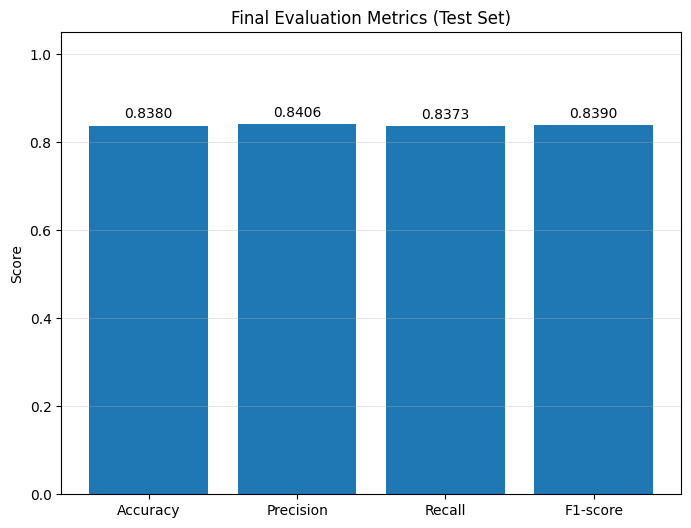

In [7]:
# -*- coding: utf-8 -*-
"""
Hybrid DistilBERT + BiGRU Pipeline - Full IMDb Dataset
Optimized to reduce overfitting, with regularization, LayerNorm, label smoothing, scheduler, and mixed precision.
Includes training, validation, testing, visualizations, CSV/JSON logging.
"""

import os, json, time, random, csv
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)

from transformers import DistilBertTokenizerFast, DistilBertModel, get_cosine_schedule_with_warmup
from tqdm.auto import tqdm

# ===================== CONFIG =====================
CONFIG = {
    "model_name": "distilbert-base-uncased",
    "max_len": 256,
    "batch_size": 32,
    "epochs": 30,
    "lr": 1.99e-05,
    "patience": 5,
    "seed": 42,
    "num_labels": 2,
    "weight_decay": 0.01
}

# ===================== REPRO =====================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== RUN FOLDER =====================
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
SAVE_DIR = f"runs/run_distilbertbigru_{RUN_ID}"
os.makedirs(SAVE_DIR, exist_ok=True)

with open(f"{SAVE_DIR}/config.json", "w") as f:
    json.dump(CONFIG, f, indent=4)

# ===================== DATASET =====================
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        enc = tokenizer(list(texts), truncation=True, padding=True, max_length=CONFIG["max_len"], return_tensors="pt")
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = torch.tensor(labels.values)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }

# ===================== MODEL =====================
class DistilBERT_BiGRU_MixPooling(nn.Module):
    def __init__(self, model_name="distilbert-base-uncased", hidden_size=128, dropout_bert=0.5, dropout_gru=0.5):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(model_name)
        self.gru = nn.GRU(input_size=768, hidden_size=hidden_size, num_layers=1, batch_first=True, bidirectional=True)
        self.layernorm = nn.LayerNorm(hidden_size*2)
        self.classifier = nn.Sequential(nn.Linear(hidden_size*2*2,128), nn.ReLU(), nn.Dropout(dropout_bert), nn.Linear(128, CONFIG["num_labels"]))

    def masked_mean(self, x, mask):
        mask = mask.unsqueeze(-1).to(x.dtype)
        summed = torch.sum(x * mask, dim=1)
        counts = torch.clamp(mask.sum(dim=1), min=1e-9)
        return summed / counts

    def masked_max(self, x, mask):
        mask = mask.unsqueeze(-1)
        x = x.masked_fill(mask == 0, -1e9)
        return torch.max(x, dim=1)[0]

    def forward(self, input_ids, attention_mask):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        gru_out, _ = self.gru(bert_out)
        gru_out = self.layernorm(gru_out)
        mean_pool = self.masked_mean(gru_out, attention_mask)
        max_pool = self.masked_max(gru_out, attention_mask)
        pooled = torch.cat([mean_pool, max_pool], dim=1)
        logits = self.classifier(pooled)
        return logits

# ===================== LOAD DATA =====================
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/TESIS FIX/IMDB Dataset.csv").dropna()
df=df.sample(n=5000,random_state=42).reset_index(drop=True)
df["sentiment"] = df["sentiment"].map({"negative":0, "positive":1})
train_val_df, test_df = train_test_split(df, test_size=0.1, stratify=df["sentiment"], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.1111, stratify=train_val_df["sentiment"], random_state=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

start_tok = time.time()
tokenizer = DistilBertTokenizerFast.from_pretrained(CONFIG["model_name"])
token_time = time.time()-start_tok

train_loader = DataLoader(TextDataset(train_df["review"], train_df["sentiment"], tokenizer), batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(TextDataset(val_df["review"], val_df["sentiment"], tokenizer), batch_size=CONFIG["batch_size"])
test_loader = DataLoader(TextDataset(test_df["review"], test_df["sentiment"], tokenizer), batch_size=CONFIG["batch_size"])

# ===================== INIT =====================
model = DistilBERT_BiGRU_MixPooling().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
total_steps = len(train_loader)*CONFIG["epochs"]
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
scaler = torch.cuda.amp.GradScaler()

# ===================== RUN EPOCH =====================
def run_epoch(loader, train=True, desc=""):
    model.train() if train else model.eval()
    preds, labels, probs = [], [], []
    total_loss, total_count = 0,0
    for batch in tqdm(loader, desc=desc, leave=False):
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        y = batch["labels"].to(device)
        optimizer.zero_grad() if train else None
        with torch.set_grad_enabled(train):
            with torch.cuda.amp.autocast():
                logits = model(ids, mask)
                loss = criterion(logits, y)
            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
        bs = y.size(0)
        total_loss += loss.item()*bs
        total_count += bs
        soft = torch.softmax(logits,1)[:,1]
        preds.extend(torch.argmax(logits,1).cpu().numpy())
        labels.extend(y.cpu().numpy())
        probs.extend(soft.detach().cpu().numpy())
    avg_loss = total_loss/total_count
    return avg_loss, accuracy_score(labels,preds), precision_score(labels,preds,zero_division=0), recall_score(labels,preds,zero_division=0), f1_score(labels,preds,zero_division=0), labels, probs

# ===================== TRAIN LOOP =====================
history=[]
best_val_f1=0
patience=0
train_start=time.time()
for epoch in range(CONFIG["epochs"]):
    tr = run_epoch(train_loader, True, f"Train Epoch {epoch+1}")
    val = run_epoch(val_loader, False, f"Val Epoch {epoch+1}")
    history.append([epoch+1,*tr[:5],*val[:5]])
    val_f1 = val[4]
    if val_f1>best_val_f1:
        best_val_f1=val_f1
        patience=0
        torch.save(model.state_dict(), f"{SAVE_DIR}/best_model_distilbertbigru_pt")
    else:
        patience+=1
        if patience>=CONFIG["patience"]:
            print(f"⛔ Early stopping at epoch {epoch+1}")
            break
training_time = time.time()-train_start

# ===================== TEST =====================
model.load_state_dict(torch.load(f"{SAVE_DIR}/best_model_distilbertbigru_pt"))
test_start=time.time()
test = run_epoch(test_loader, False, "Test")
test_time = time.time()-test_start

test_loss, test_acc, test_prec, test_rec, test_f1, test_labels, test_probs = test

# ===================== CONFUSION MATRIX =====================
test_preds = (np.array(test_probs)>=0.5).astype(int)
cm = confusion_matrix(test_labels,test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative","Positive"])
plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Test Set)")
plt.grid(False)
plt.savefig(f"{SAVE_DIR}/confusion_matrix.png")
plt.close()

# ===================== CSV LOG =====================
with open(f"{SAVE_DIR}/training_log.csv","w",newline="") as f:
    writer=csv.writer(f)
    writer.writerow(["epoch","train_loss","train_acc","train_prec","train_rec","train_f1","val_loss","val_acc","val_prec","val_rec","val_f1"])
    writer.writerows(history)
    writer.writerow(["TEST_FINAL", test_loss, test_acc, test_prec, test_rec, test_f1, "-","-","-","-","-"])

# ===================== EXPERIMENT SUMMARY =====================
total_execution_time = token_time+training_time+test_time
summary={"model":CONFIG["model_name"], "seed":CONFIG["seed"], "epochs_trained":len(history), "batch_size":CONFIG["batch_size"], "learning_rate":CONFIG["lr"], "test_metrics":{"loss":test_loss, "accuracy":test_acc, "precision":test_prec, "recall":test_rec, "f1":test_f1}, "timing":{"tokenization_time":token_time,"training_time":training_time,"test_time":test_time,"total_time":total_execution_time}}

with open(f"{SAVE_DIR}/experiment_summary.json","w") as f: json.dump(summary,f,indent=4)
with open(f"{SAVE_DIR}/experiment_summary.csv","w",newline="") as f:
    writer=csv.writer(f)
    writer.writerow(["tokenization_time","training_time","test_time","total_execution_time"])
    writer.writerow([token_time, training_time, test_time, total_execution_time])

# ===================== LEARNING CURVES & METRICS PLOTS =====================
epochs=[h[0] for h in history]

plt.figure(figsize=(10,6))
plt.plot(epochs,[h[2] for h in history],label="Train Acc")
plt.plot(epochs,[h[7] for h in history],label="Val Acc")
plt.axhline(test_acc,linestyle="--",label=f"Test Acc {test_acc:.4f}")
plt.title("Accuracy Curve DistilBERT-BiGRU")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{SAVE_DIR}/accuracy_curve.png")
plt.close()

plt.figure(figsize=(10,6))
plt.plot(epochs,[h[1] for h in history],label="Train Loss")
plt.plot(epochs,[h[6] for h in history],label="Val Loss")
plt.axhline(test_loss,linestyle="--",label=f"Test Loss {test_loss:.4f}")
plt.title("Loss Curve DistilBERT-BiGRU")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{SAVE_DIR}/loss_curve.png")
plt.close()

# ===================== ROC & PR CURVES =====================
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set) DistilBERT-BiGRU")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{SAVE_DIR}/roc_curve.png")
plt.close()

precision, recall, _ = precision_recall_curve(test_labels, test_probs)
pr_auc = average_precision_score(test_labels, test_probs)
plt.figure(figsize=(8,6))
plt.plot(recall, precision,label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test Set)")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{SAVE_DIR}/pr_curve.png")
plt.close()

# ===================== FINAL EVALUATION BAR =====================
metrics={"Accuracy":test_acc,"Precision":test_prec,"Recall":test_rec,"F1-score":test_f1}
names=list(metrics.keys())
values=list(metrics.values())
plt.figure(figsize=(8,6))
bars=plt.bar(names,values)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,f"{bar.get_height():.4f}",ha='center',va='bottom')
plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("Final Evaluation Metrics (Test Set)")
plt.grid(axis='y',alpha=0.3)
plt.savefig(f"{SAVE_DIR}/final_evaluation_metrics.png")
plt.show()

# ===================== TIME LOG =====================
with open(f"{SAVE_DIR}/time_log.json","w") as f:
    json.dump({"tokenization_time":token_time,"training_time":training_time,"test_time":test_time},f,indent=4)


TEST

In [9]:
# -*- coding: utf-8 -*-
"""
Hybrid DistilBERT + BiGRU Pipeline - Full IMDb Dataset
Optimized to reduce overfitting, with regularization, LayerNorm, label smoothing, scheduler, and mixed precision.
Includes training, validation, testing, visualizations, CSV/JSON logging.
"""

import os, json, time, random, csv
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)

from transformers import DistilBertTokenizerFast, DistilBertModel, get_cosine_schedule_with_warmup
from tqdm.auto import tqdm

# ===================== CONFIG =====================
CONFIG = {
    "model_name": "distilbert-base-uncased",
    "max_len": 256,
    "batch_size": 32,
    "epochs": 30,
    "lr": 1.99e-05,
    "patience": 5,
    "seed": 42,
    "num_labels": 2,
    "weight_decay": 0.01
}

# ===================== REPRO =====================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== RUN FOLDER =====================
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
SAVE_DIR = f"runs/run_distilbertbigru_{RUN_ID}"
os.makedirs(SAVE_DIR, exist_ok=True)

with open(f"{SAVE_DIR}/config.json", "w") as f:
    json.dump(CONFIG, f, indent=4)

# ===================== DATASET =====================
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        enc = tokenizer(list(texts), truncation=True, padding=True, max_length=CONFIG["max_len"], return_tensors="pt")
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = torch.tensor(labels.values)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }
# =========================================================
# MODEL
# =========================================================
class DistilBERT_BiGRU(nn.Module):
    def __init__(self,
                 model_name="distilbert-base-uncased",
                 hidden_dim=128,
                 num_classes=2,
                 dropout=0.3):

        super().__init__()

        self.bert = DistilBertModel.from_pretrained(model_name)

        # Freeze first 3 layers (anti overfitting)
        for layer in self.bert.transformer.layer[:3]:
            for param in layer.parameters():
                param.requires_grad = False

        emb_dim = self.bert.config.hidden_size

        self.bigru = nn.GRU(
            emb_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*4, num_classes)

    def forward(self, input_ids, attention_mask):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        x = outputs.last_hidden_state

        x,_ = self.bigru(x)

        avg_pool = torch.mean(x,1)
        max_pool,_ = torch.max(x,1)

        feat = torch.cat([avg_pool,max_pool],1)

        return self.fc(self.dropout(feat))


# ===================== LOAD DATA =====================
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/TESIS FIX/IMDB Dataset.csv").dropna()
df=df.sample(n=5000,random_state=42).reset_index(drop=True)
df["sentiment"] = df["sentiment"].map({"negative":0, "positive":1})
train_val_df, test_df = train_test_split(df, test_size=0.1, stratify=df["sentiment"], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.1111, stratify=train_val_df["sentiment"], random_state=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

start_tok = time.time()
tokenizer = DistilBertTokenizerFast.from_pretrained(CONFIG["model_name"])
token_time = time.time()-start_tok

train_loader = DataLoader(TextDataset(train_df["review"], train_df["sentiment"], tokenizer), batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(TextDataset(val_df["review"], val_df["sentiment"], tokenizer), batch_size=CONFIG["batch_size"])
test_loader = DataLoader(TextDataset(test_df["review"], test_df["sentiment"], tokenizer), batch_size=CONFIG["batch_size"])

# ===================== INIT =====================
"""model = DistilBERT_BiGRU_MixPooling().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
total_steps = len(train_loader)*CONFIG["epochs"]
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
scaler = torch.cuda.amp.GradScaler()
"""

model = DistilBERT_BiGRU().to(device)
import torch.optim as optim

optimizer = optim.AdamW([
    {"params": model.bert.parameters(), "lr":2e-5},
    {"params": model.bigru.parameters(), "lr":1e-4},
    {"params": model.fc.parameters(), "lr":1e-4}
], weight_decay=0.01)

total_steps = len(train_loader)*epochs

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[2e-5,1e-4,1e-4],
    total_steps=total_steps
)

# ===================== RUN EPOCH =====================
def RUN_epoch(model,loader):

    model.train()
    total_loss,correct=0,0

    for ids,mask,labels in loader:

        ids,mask,labels=ids.to(device),mask.to(device),labels.to(device)

        optimizer.zero_grad()

        logits=model(ids,mask)

        loss=criterion(logits,labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

        optimizer.step()
        scheduler.step()

        total_loss+=loss.item()

        preds=torch.argmax(logits,1)
        correct+=(preds==labels).sum().item()

    return total_loss/len(loader),correct/len(loader.dataset)

# ===================== TRAIN LOOP =====================
history=[]
best_val_f1=0
patience=0
train_start=time.time()
for epoch in range(CONFIG["epochs"]):
    tr = run_epoch(train_loader, True, f"Train Epoch {epoch+1}")
    val = run_epoch(val_loader, False, f"Val Epoch {epoch+1}")
    history.append([epoch+1,*tr[:5],*val[:5]])
    val_f1 = val[4]
    if val_f1>best_val_f1:
        best_val_f1=val_f1
        patience=0
        torch.save(model.state_dict(), f"{SAVE_DIR}/best_model_distilbertbigru_pt")
    else:
        patience+=1
        if patience>=CONFIG["patience"]:
            print(f"⛔ Early stopping at epoch {epoch+1}")
            break
training_time = time.time()-train_start

# ===================== TEST =====================
model.load_state_dict(torch.load(f"{SAVE_DIR}/best_model_distilbertbigru_pt"))
test_start=time.time()
test = run_epoch(test_loader, False, "Test")
test_time = time.time()-test_start

test_loss, test_acc, test_prec, test_rec, test_f1, test_labels, test_probs = test

# ===================== CONFUSION MATRIX =====================
test_preds = (np.array(test_probs)>=0.5).astype(int)
cm = confusion_matrix(test_labels,test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative","Positive"])
plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Test Set)")
plt.grid(False)
plt.savefig(f"{SAVE_DIR}/confusion_matrix.png")
plt.close()

# ===================== CSV LOG =====================
with open(f"{SAVE_DIR}/training_log.csv","w",newline="") as f:
    writer=csv.writer(f)
    writer.writerow(["epoch","train_loss","train_acc","train_prec","train_rec","train_f1","val_loss","val_acc","val_prec","val_rec","val_f1"])
    writer.writerows(history)
    writer.writerow(["TEST_FINAL", test_loss, test_acc, test_prec, test_rec, test_f1, "-","-","-","-","-"])

# ===================== EXPERIMENT SUMMARY =====================
total_execution_time = token_time+training_time+test_time
summary={"model":CONFIG["model_name"], "seed":CONFIG["seed"], "epochs_trained":len(history), "batch_size":CONFIG["batch_size"], "learning_rate":CONFIG["lr"], "test_metrics":{"loss":test_loss, "accuracy":test_acc, "precision":test_prec, "recall":test_rec, "f1":test_f1}, "timing":{"tokenization_time":token_time,"training_time":training_time,"test_time":test_time,"total_time":total_execution_time}}

with open(f"{SAVE_DIR}/experiment_summary.json","w") as f: json.dump(summary,f,indent=4)
with open(f"{SAVE_DIR}/experiment_summary.csv","w",newline="") as f:
    writer=csv.writer(f)
    writer.writerow(["tokenization_time","training_time","test_time","total_execution_time"])
    writer.writerow([token_time, training_time, test_time, total_execution_time])

# ===================== LEARNING CURVES & METRICS PLOTS =====================
epochs=[h[0] for h in history]

plt.figure(figsize=(10,6))
plt.plot(epochs,[h[2] for h in history],label="Train Acc")
plt.plot(epochs,[h[7] for h in history],label="Val Acc")
plt.axhline(test_acc,linestyle="--",label=f"Test Acc {test_acc:.4f}")
plt.title("Accuracy Curve DistilBERT-BiGRU")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{SAVE_DIR}/accuracy_curve.png")
plt.close()

plt.figure(figsize=(10,6))
plt.plot(epochs,[h[1] for h in history],label="Train Loss")
plt.plot(epochs,[h[6] for h in history],label="Val Loss")
plt.axhline(test_loss,linestyle="--",label=f"Test Loss {test_loss:.4f}")
plt.title("Loss Curve DistilBERT-BiGRU")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{SAVE_DIR}/loss_curve.png")
plt.close()

# ===================== ROC & PR CURVES =====================
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set) DistilBERT-BiGRU")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{SAVE_DIR}/roc_curve.png")
plt.close()

precision, recall, _ = precision_recall_curve(test_labels, test_probs)
pr_auc = average_precision_score(test_labels, test_probs)
plt.figure(figsize=(8,6))
plt.plot(recall, precision,label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test Set)")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{SAVE_DIR}/pr_curve.png")
plt.close()

# ===================== FINAL EVALUATION BAR =====================
metrics={"Accuracy":test_acc,"Precision":test_prec,"Recall":test_rec,"F1-score":test_f1}
names=list(metrics.keys())
values=list(metrics.values())
plt.figure(figsize=(8,6))
bars=plt.bar(names,values)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,f"{bar.get_height():.4f}",ha='center',va='bottom')
plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("Final Evaluation Metrics (Test Set)")
plt.grid(axis='y',alpha=0.3)
plt.savefig(f"{SAVE_DIR}/final_evaluation_metrics.png")
plt.show()

# ===================== TIME LOG =====================
with open(f"{SAVE_DIR}/time_log.json","w") as f:
    json.dump({"tokenization_time":token_time,"training_time":training_time,"test_time":test_time},f,indent=4)


Train: 4000 | Val: 500 | Test: 500


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TypeError: '<=' not supported between instances of 'list' and 'int'